# 📰 Fake News Detection — EDA & LSTM Training
**Dataset:** [ISOT Fake News Dataset](https://www.kaggle.com/datasets/emineyetm/fake-and-real-news-dataset) or [WELFake](https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification)

**Pipeline:**
1. Load & inspect data
2. EDA — distributions, word clouds, length analysis
3. Text preprocessing
4. Tokenization + Padding
5. LSTM model architecture
6. Train + evaluate
7. Save model + tokenizer

In [11]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re, string, pickle, os

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout, Bidirectional,
    SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')

[nltk_data] Downloading package stopwords to C:\Users\Joshi
[nltk_data]     Mayuresh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Joshi
[nltk_data]     Mayuresh\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\Joshi
[nltk_data]     Mayuresh\AppData\Roaming\nltk_data...


TensorFlow version: 2.21.0


## 1. Load Data
Download from Kaggle: [ISOT Dataset](https://www.kaggle.com/datasets/emineyetm/fake-and-real-news-dataset)  
Place `True.csv` and `Fake.csv` inside the `data/` folder.

In [12]:
# ── Load ISOT dataset ─────────────────────────────────────────────────────────
true_df  = pd.read_csv('../data/True.csv')
fake_df  = pd.read_csv('../data/Fake.csv')

true_df['label'] = 1   # 1 = REAL
fake_df['label'] = 0   # 0 = FAKE

df = pd.concat([true_df, fake_df], ignore_index=True)

# Combine title + text for richer signal
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df = df[['content', 'label']].sample(frac=1, random_state=SEED).reset_index(drop=True)

print(df.shape)
df.head()

(44898, 2)


,content,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,0
1,Failed GOP Candidates Remembered In Hilarious...,0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,0
3,California AG pledges to defend birth control ...,1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,0


## 2. Exploratory Data Analysis

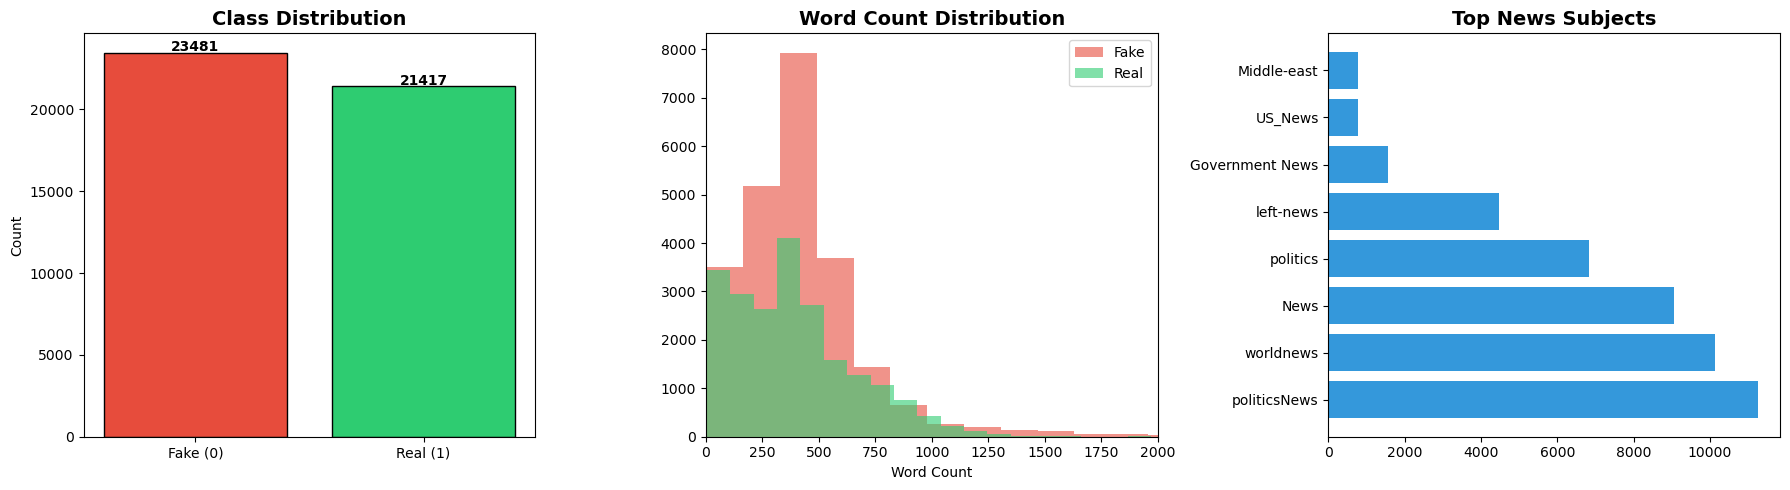


Dataset stats:
  Total articles : 44,898
  Real news      : 21,417 (47.7%)
  Fake news      : 23,481 (52.3%)
  Avg word count : 418
  Max word count : 8,148


In [13]:
# ── Class distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class balance
counts = df['label'].value_counts()
axes[0].bar(['Fake (0)', 'Real (1)'], counts.values, color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Article length distribution
df['word_count'] = df['content'].apply(lambda x: len(x.split()))
for label, color, name in [(0,'#e74c3c','Fake'), (1,'#2ecc71','Real')]:
    axes[1].hist(df[df['label']==label]['word_count'], bins=50,
                 alpha=0.6, color=color, label=name)
axes[1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()
axes[1].set_xlim(0, 2000)

# Top subjects (if ISOT)
if 'subject' in true_df.columns:
    subj = pd.concat([true_df['subject'], fake_df['subject']]).value_counts().head(10)
    axes[2].barh(subj.index, subj.values, color='#3498db')
    axes[2].set_title('Top News Subjects', fontsize=14, fontweight='bold')
else:
    axes[2].axis('off')

plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDataset stats:")
print(f"  Total articles : {len(df):,}")
print(f"  Real news      : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")
print(f"  Fake news      : {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"  Avg word count : {df['word_count'].mean():.0f}")
print(f"  Max word count : {df['word_count'].max():,}")

C:\Users\Joshi Mayuresh\AppData\Local\Temp\ipykernel_26968\115671876.py:17: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Joshi Mayuresh\AppData\Local\Temp\ipykernel_26968\115671876.py:17: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Joshi Mayuresh\AppData\Local\Temp\ipykernel_26968\115671876.py:18: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('../data/wordclouds.png', dpi=150, bbox_inches='tight')
C:\Users\Joshi Mayuresh\AppData\Local\Temp\ipykernel_26968\115671876.py:18: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('../data/wordclouds.png', dpi=150, bbox_inches='tight')
d:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

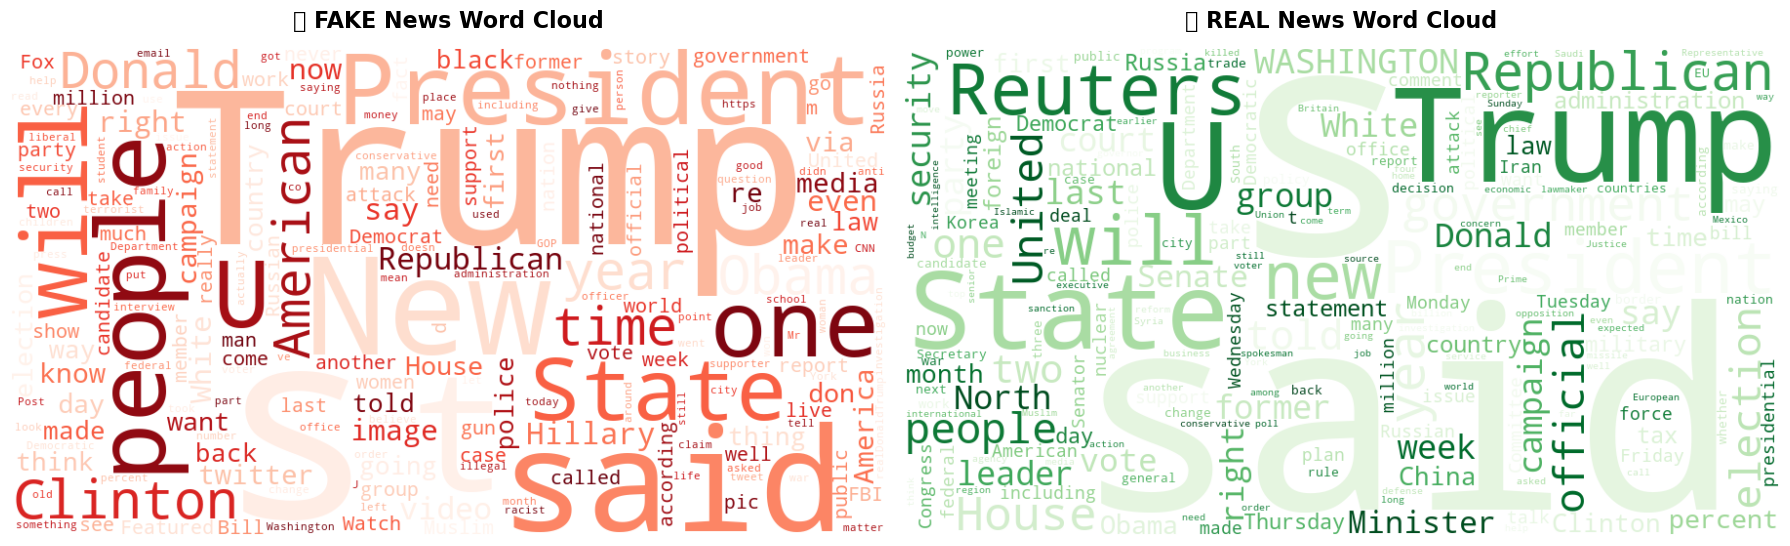

In [14]:
# ── Word Clouds ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, label, title, colormap in [
    (axes[0], 0, '🔴 FAKE News Word Cloud', 'Reds'),
    (axes[1], 1, '🟢 REAL News Word Cloud', 'Greens')
]:
    text = ' '.join(df[df['label']==label]['content'].sample(5000, random_state=SEED))
    wc = WordCloud(
        width=900, height=500, background_color='white',
        colormap=colormap, max_words=200, collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../data/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Text Preprocessing

In [15]:
# ── Preprocessing pipeline ────────────────────────────────────────────────────
lemmatizer   = WordNetLemmatizer()
stop_words   = set(stopwords.words('english'))

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)        # remove URLs
    text = re.sub(r'<.*?>', '', text)                          # remove HTML tags
    text = re.sub(r'\[.*?\]', '', text)                        # remove brackets
    text = re.sub(r'[^a-z\s]', '', text)                       # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()                   # collapse whitespace
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print('Preprocessing text (takes ~2 min)...')
df['clean_content'] = df['content'].apply(preprocess)

# Sanity check
print('\nBefore:', df['content'].iloc[0][:200])
print('\nAfter :', df['clean_content'].iloc[0][:200])

Preprocessing text (takes ~2 min)...

Before:  BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour,

After : breaking gop chairman grassley enough demand trump testimony donald trump white house chaos trying cover russia problem mounting hour refuse acknowledge problem surrounding fake news hoax however fact


## 4. Tokenization & Sequence Padding

In [16]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
VOCAB_SIZE   = 20000
MAX_LEN      = 216      # truncate/pad to 512 tokens
EMBED_DIM    = 128
LSTM_UNITS   = 128
BATCH_SIZE   = 64
EPOCHS       = 10

# ── Train/Val/Test split ──────────────────────────────────────────────────────
X = df['clean_content'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val   = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train)

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)            # fit ONLY on train

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_pad = encode(X_train)
X_val_pad   = encode(X_val)
X_test_pad  = encode(X_test)

print(f'\nPadded shape: {X_train_pad.shape}')
print(f'Vocab size  : {len(tokenizer.word_index):,} unique tokens')

# Save tokenizer for inference
os.makedirs('../models', exist_ok=True)
with open('../models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('✅ Tokenizer saved.')

Train: 32,438 | Val: 5,725 | Test: 6,735

Padded shape: (32438, 216)
Vocab size  : 171,895 unique tokens
✅ Tokenizer saved.


## 5. Bidirectional LSTM Model

In [21]:
# ── Model architecture (Functional API) ──────────────────────────────────────
# Using Functional API with explicit Input layer instead of Sequential.
# This ensures shapes are built immediately and .summary() shows real param counts.
# Also avoids the 'NotEqual' serialisation error when saving/loading across
# Keras 2 / Keras 3 versions.

def build_bilstm_model():
    # Explicit input — shapes are inferred immediately
    inputs = tf.keras.Input(shape=(MAX_LEN,), dtype='int32', name='token_ids')

    # Embedding: token IDs → 128-dim dense vectors
    x = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                  mask_zero=True, name='embedding')(inputs)
    x = SpatialDropout1D(0.3)(x)

    # Bidirectional LSTM layer 1 — reads sequence forward + backward
    x = Bidirectional(LSTM(LSTM_UNITS, return_sequences=True,
                           dropout=0.3, recurrent_dropout=0.2,
                           kernel_regularizer=l2(1e-4)),
                      name='bilstm_1')(x)

    # Bidirectional LSTM layer 2 — learns higher-level patterns
    x = Bidirectional(LSTM(LSTM_UNITS // 2, return_sequences=True,
                           dropout=0.3, recurrent_dropout=0.2),
                      name='bilstm_2')(x)

    # GlobalMaxPooling — picks the most activated feature across all time steps
    x = GlobalMaxPooling1D()(x)

    # Dense classification head
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='BiLSTM_FakeNews')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

model = build_bilstm_model()
model.summary()

d:\Anaconda3\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'global_max_pooling1d_2' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "BiLSTM_FakeNews"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 216)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 216, 128)  │  2,560,000 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 216, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 216)       │          0 │ token_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 216, 256)  │    263,168 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 216, 128)  │    164,352 │ bilstm_1[0][0],   │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bilstm_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     16,512 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,012,353 (11.49 MB)

 Trainable params: 3,012,353 (11.49 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [ ]:
# Save as .keras (native format) — avoids the Keras 2/3 'NotEqual' error
# when loading the model locally. The .keras format is version-stable.
import os
os.makedirs('../models', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True, mode='max', verbose=1),
    ModelCheckpoint('../models/best_model.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# ── Fit ───────────────────────────────────────────────────────────────────────
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

## 7. Training Curves

In [ ]:
# ── Plot training history ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [('loss', 'Loss'), ('accuracy', 'Accuracy'), ('auc', 'ROC-AUC')]
for ax, (metric, title) in zip(axes, metrics):
    ax.plot(history.history[metric],        label='Train', color='#3498db', lw=2)
    ax.plot(history.history[f'val_{metric}'], label='Val', color='#e74c3c', lw=2, ls='--')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training History — Bidirectional LSTM', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation on Test Set

In [ ]:
# ── Test evaluation ───────────────────────────────────────────────────────────
y_pred_prob = model.predict(X_test_pad, batch_size=128).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print('=' * 60)
print('TEST SET RESULTS')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}')

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Save model config ─────────────────────────────────────────────────────────
import json

config = {
    'VOCAB_SIZE': VOCAB_SIZE,
    'MAX_LEN'   : MAX_LEN,
    'EMBED_DIM' : EMBED_DIM,
    'LSTM_UNITS': LSTM_UNITS,
    'test_accuracy': float((y_pred == y_test).mean()),
    'test_auc'      : float(auc_score)
}

with open('../models/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Model, tokenizer & config saved to ../models/')
print(f"\n Final Test Accuracy : {config['test_accuracy']*100:.2f}%")
print(f" Final Test AUC      : {config['test_auc']:.4f}")